<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

In [3]:
#!pip install seaborn

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [5]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
df.duplicated().sum()

np.int64(0)

###There are no duplicate rows

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [7]:
df['CodingActivities'].isnull().value_counts()

CodingActivities
False    54466
True     10971
Name: count, dtype: int64

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
df['CodingActivities'] = df['CodingActivities'].ffill()
df['CodingActivities'].isnull().value_counts()

CodingActivities
False    65437
Name: count, dtype: int64

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [9]:
df['ConvertedCompYearly'].isnull().value_counts()

ConvertedCompYearly
True     42002
False    23435
Name: count, dtype: int64

In [10]:
#64% of the rows have NaN for this column; I think so that, if we want to do any analysis concerning compensation, we should drop these rows, the results will be more reliable this way
#we will still have a good number of rows (23435) in our dataset
# for other analysis, which do not involve compensation, we can keep these rows, of course
df_with_comp = df.dropna(subset='ConvertedCompYearly')
df_with_comp = df_with_comp.reset_index(drop=True)
df_with_comp['ConvertedCompYearly'].isnull().value_counts()

ConvertedCompYearly
False    23435
Name: count, dtype: int64

### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [11]:
#let's see the characteristics of ConvertedCompYearly
df_with_comp['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [12]:
#The maximum value is quite large; it would be interesting to look for outliers and deal with them
#the inter quantile range is around 75.26 so if we consider any value above Q3 + 1.5 IQR (around 221) as an outlier, we can see the number of outliers
df_with_comp[df_with_comp['ConvertedCompYearly'] > 221000]['ConvertedCompYearly'].count()

np.int64(977)

In [14]:
#outliers are just 4% of the data points, let's drop them
df_with_comp = df_with_comp[df_with_comp['ConvertedCompYearly'] <= 221000]
df_with_comp = df_with_comp.reset_index(drop=True)
df_with_comp['ConvertedCompYearly'].count()


np.int64(22458)

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [15]:
comp_range = df_with_comp['ConvertedCompYearly'].max() - df_with_comp['ConvertedCompYearly'].min()
df_with_comp['ConvertedCompYearly_MinMax'] = (df_with_comp['ConvertedCompYearly'] - df_with_comp['ConvertedCompYearly'].min() ) / comp_range
df_with_comp[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,7322.0,0.033127
1,30074.0,0.136078
2,91295.0,0.413097
3,53703.0,0.242997
4,110000.0,0.497735


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [16]:
df_with_comp['ConvertedCompYearly_Zscore'] = (df_with_comp['ConvertedCompYearly'] - df_with_comp['ConvertedCompYearly'].mean()) / df_with_comp['ConvertedCompYearly'].std()
df_with_comp[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax', 'ConvertedCompYearly_Zscore']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore
0,7322.0,0.033127,-1.248672
1,30074.0,0.136078,-0.804990
2,91295.0,0.413097,0.388868
3,53703.0,0.242997,-0.344206
4,110000.0,0.497735,0.753630


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


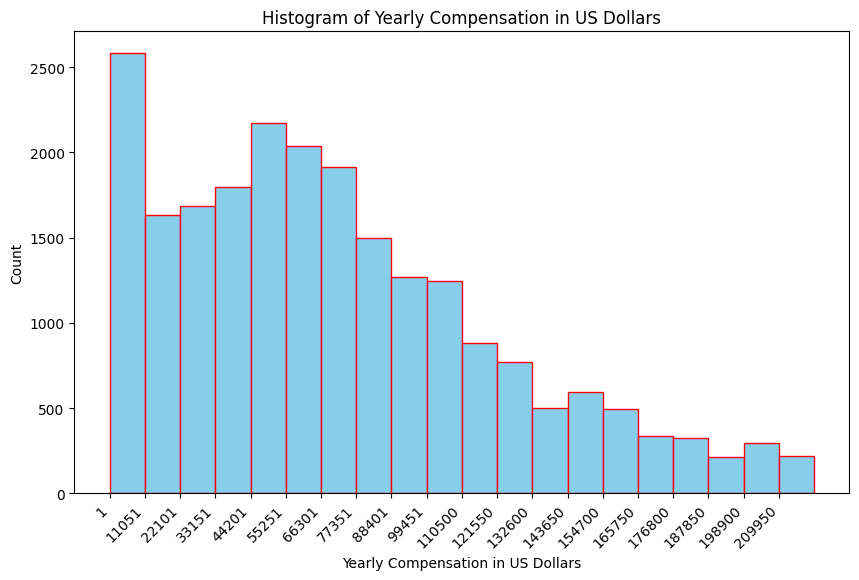

In [17]:
#Histogram for ConvertedCompYearly
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
counts, bins, patches = plt.hist(df_with_comp['ConvertedCompYearly'], bins=20, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Yearly Compensation in US Dollars')
plt.ylabel('Count')
plt.title('Histogram of Yearly Compensation in US Dollars')
plt.show()

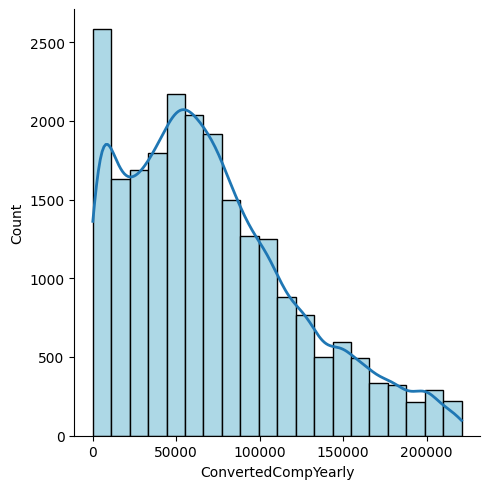

In [18]:
#Lets plot also a kde graph with the histogram using seaborn
sns.displot(
    df_with_comp['ConvertedCompYearly'],
    kde=True,
    bins=20,
    facecolor="lightblue",           # histogram fill
    edgecolor="black",               # histogram border
    line_kws={"color": "red", "lw": 2}  # KDE line style
           )

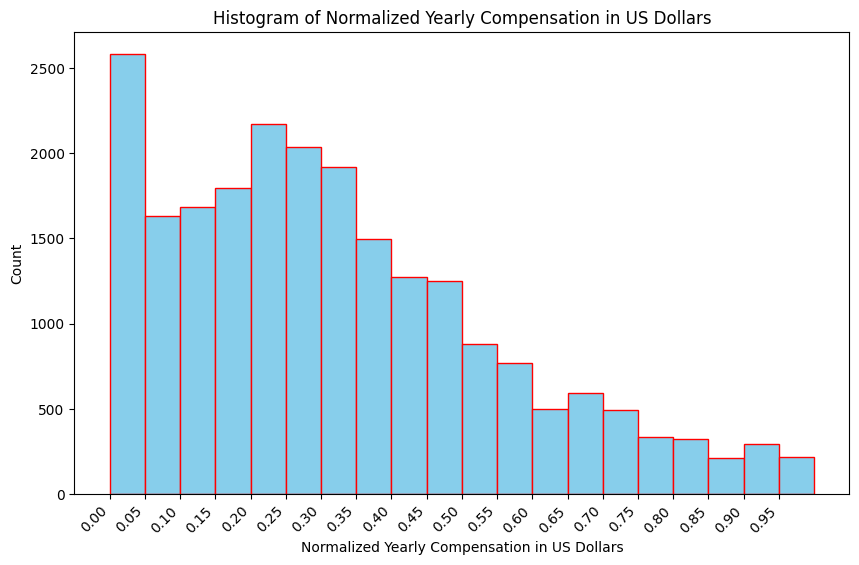

In [19]:
#Histogram for ConvertedCompYearly_MinMax	
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
counts, bins, patches = plt.hist(df_with_comp['ConvertedCompYearly_MinMax'], bins=20, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Normalized Yearly Compensation in US Dollars')
plt.ylabel('Count')
plt.title('Histogram of Normalized Yearly Compensation in US Dollars')
plt.show()

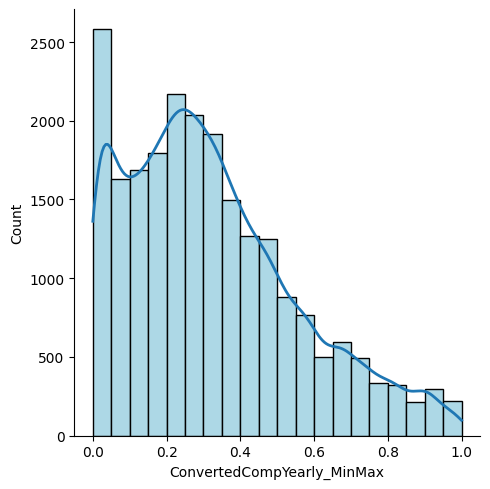

In [20]:
#Lets plot also a kde graph with the histogram using seaborn
sns.displot(
    df_with_comp['ConvertedCompYearly_MinMax'],
    kde=True,
    bins=20,
    facecolor="lightblue",           # histogram fill
    edgecolor="black",               # histogram border
    line_kws={"color": "red", "lw": 2}  # KDE line style
           )

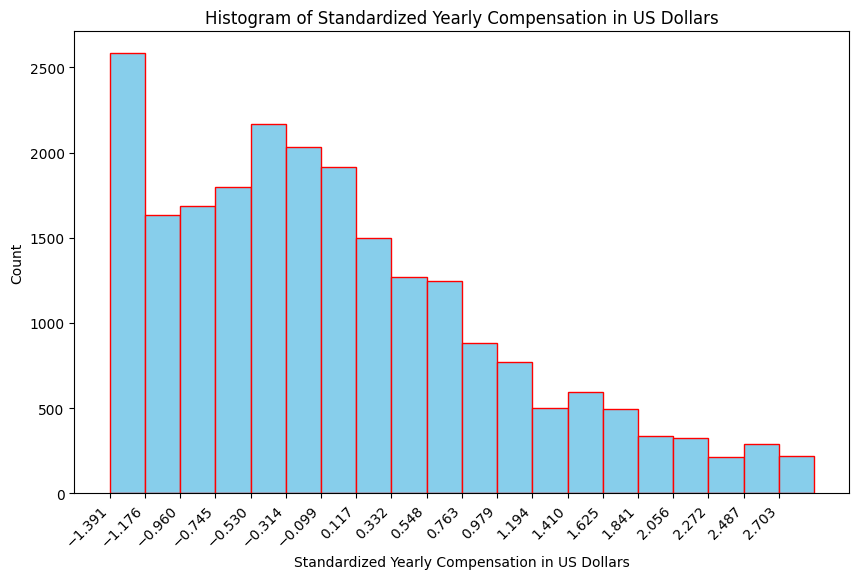

In [21]:
#Histogram for ConvertedCompYearly_Zscore	
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
counts, bins, patches = plt.hist(df_with_comp['ConvertedCompYearly_Zscore'], bins=20, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Standardized Yearly Compensation in US Dollars')
plt.ylabel('Count')
plt.title('Histogram of Standardized Yearly Compensation in US Dollars')
plt.show()

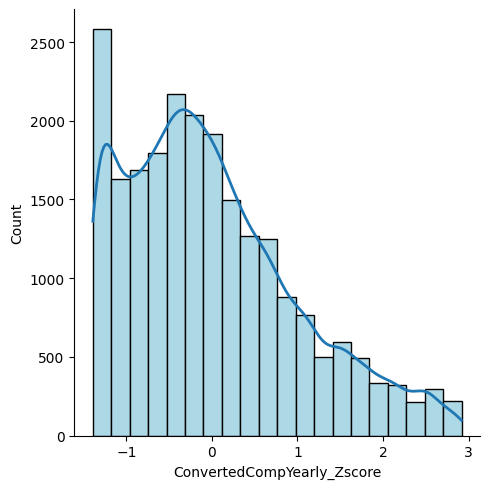

In [22]:
#Lets plot also a kde graph with the histogram using seaborn
sns.displot(
    df_with_comp['ConvertedCompYearly_Zscore'],
    kde=True,
    bins=20,
    facecolor="lightblue",           # histogram fill
    edgecolor="black",               # histogram border
    line_kws={"color": "red", "lw": 2}  # KDE line style
           )

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
